/tmp/ipykernel_271516/1796293803.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(ax=axes[0], x='view_count', y='macrotopic_pred', data=top_views, palette='viridis')
/tmp/ipykernel_271516/1796293803.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(ax=axes[1], x='like_count', y='macrotopic_pred', data=top_likes, palette='magma')
/tmp/ipykernel_271516/1796293803.py:38: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(ax=axes[2], x='comment_count', y='macrotopic_pred', data=top_comm, palette='rocket')


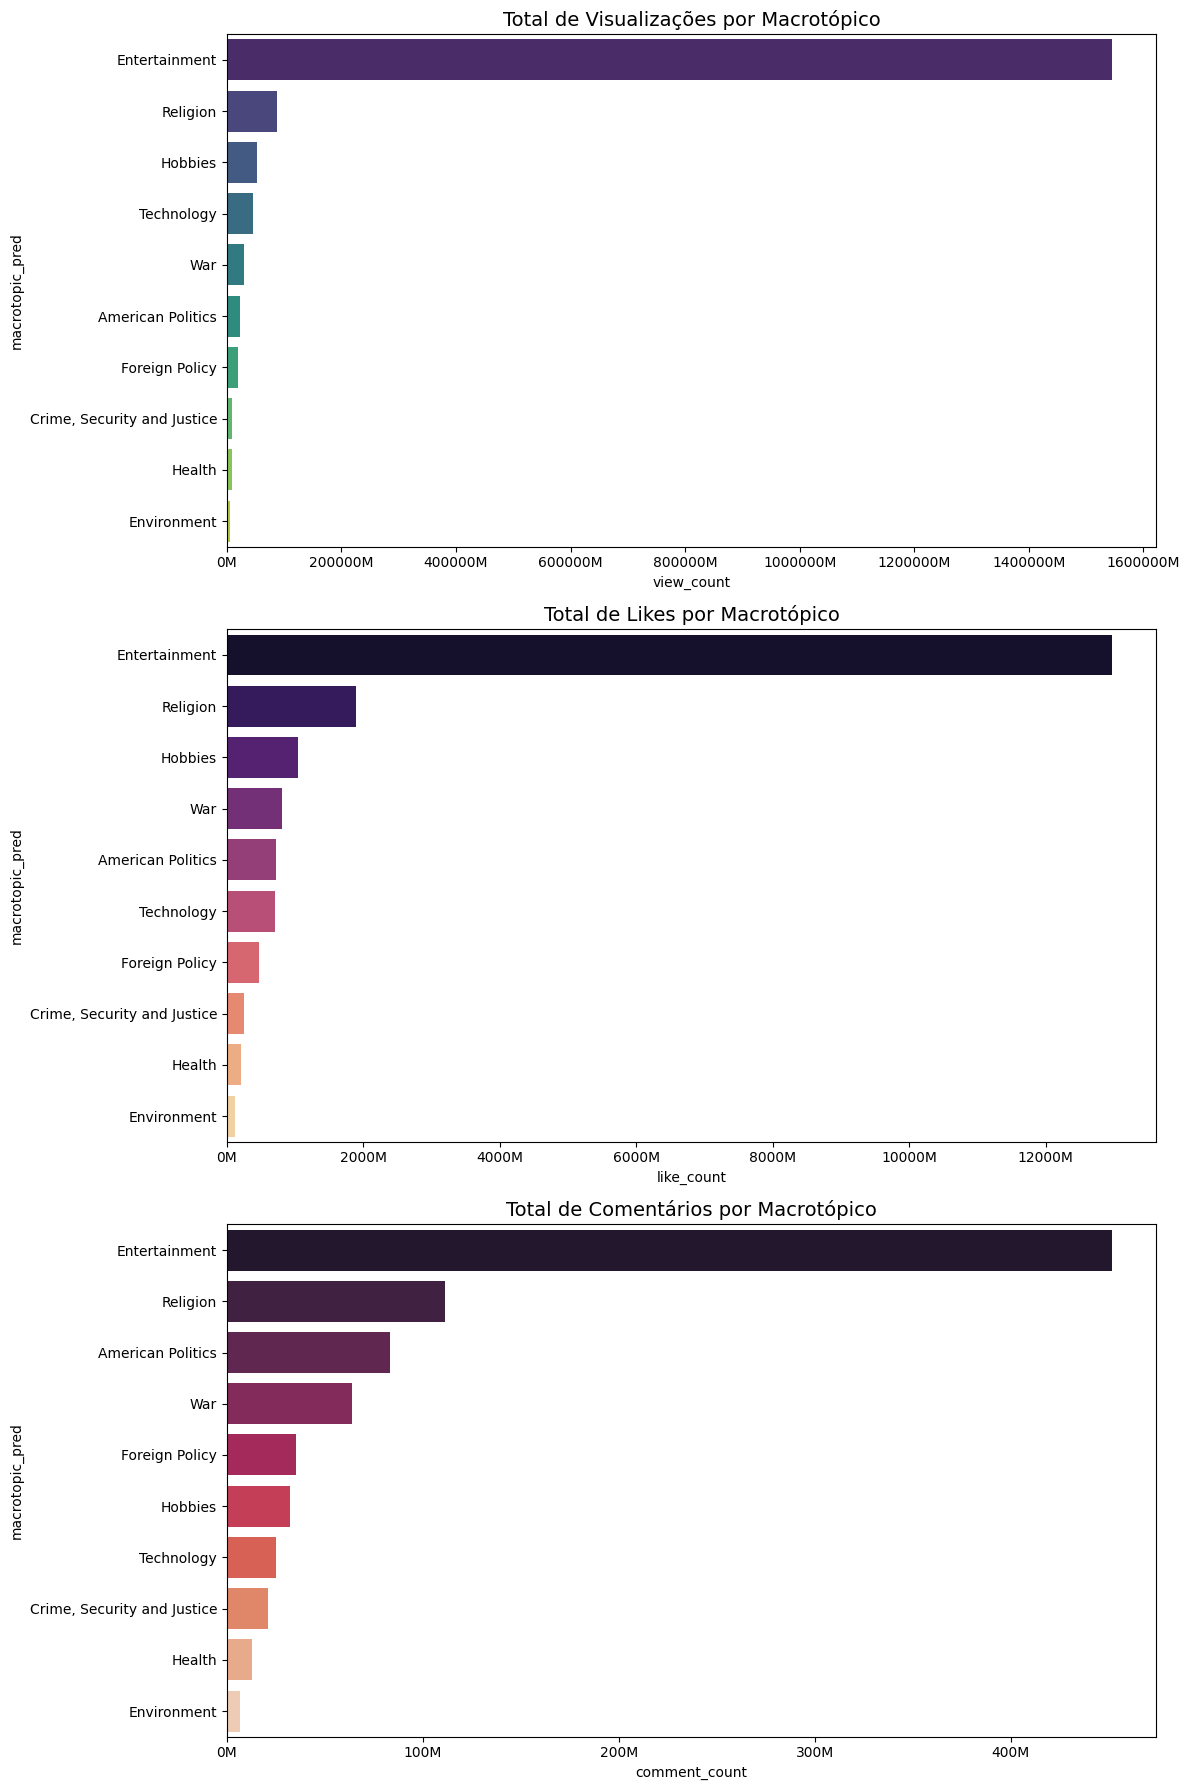

In [3]:
%matplotlib inline
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as ticker

# --- Configuração ---
INPUT_FILE = 'data/macrotopics_pred.csv' 
# --------------------

try:
    df = pd.read_csv(INPUT_FILE)
except FileNotFoundError:
    df = pd.read_csv('sample_yt_te_cross_with_topics.csv')

# Limpeza e Filtro
cols = ['view_count', 'like_count', 'comment_count']
for c in cols: df[c] = pd.to_numeric(df[c], errors='coerce').fillna(0)
df_clean = df[df['macrotopic_pred'] != 'Others'] # Remove "Outros"

# Configura 3 gráficos lado a lado
fig, axes = plt.subplots(3, 1, figsize=(12, 18))

# 1. Visualizações
top_views = df_clean.groupby('macrotopic_pred')['view_count'].sum().sort_values(ascending=False).reset_index()
sns.barplot(ax=axes[0], x='view_count', y='macrotopic_pred', data=top_views, palette='viridis')
axes[0].set_title('Total de Visualizações por Macrotópico', fontsize=14)
axes[0].xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, p: f'{x/1e6:.0f}M'))

# 2. Likes
top_likes = df_clean.groupby('macrotopic_pred')['like_count'].sum().sort_values(ascending=False).reset_index()
sns.barplot(ax=axes[1], x='like_count', y='macrotopic_pred', data=top_likes, palette='magma')
axes[1].set_title('Total de Likes por Macrotópico', fontsize=14)
axes[1].xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, p: f'{x/1e6:.0f}M'))

# 3. Comentários
top_comm = df_clean.groupby('macrotopic_pred')['comment_count'].sum().sort_values(ascending=False).reset_index()
sns.barplot(ax=axes[2], x='comment_count', y='macrotopic_pred', data=top_comm, palette='rocket')
axes[2].set_title('Total de Comentários por Macrotópico', fontsize=14)
axes[2].xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, p: f'{x/1e6:.0f}M'))

plt.tight_layout()
plt.show()

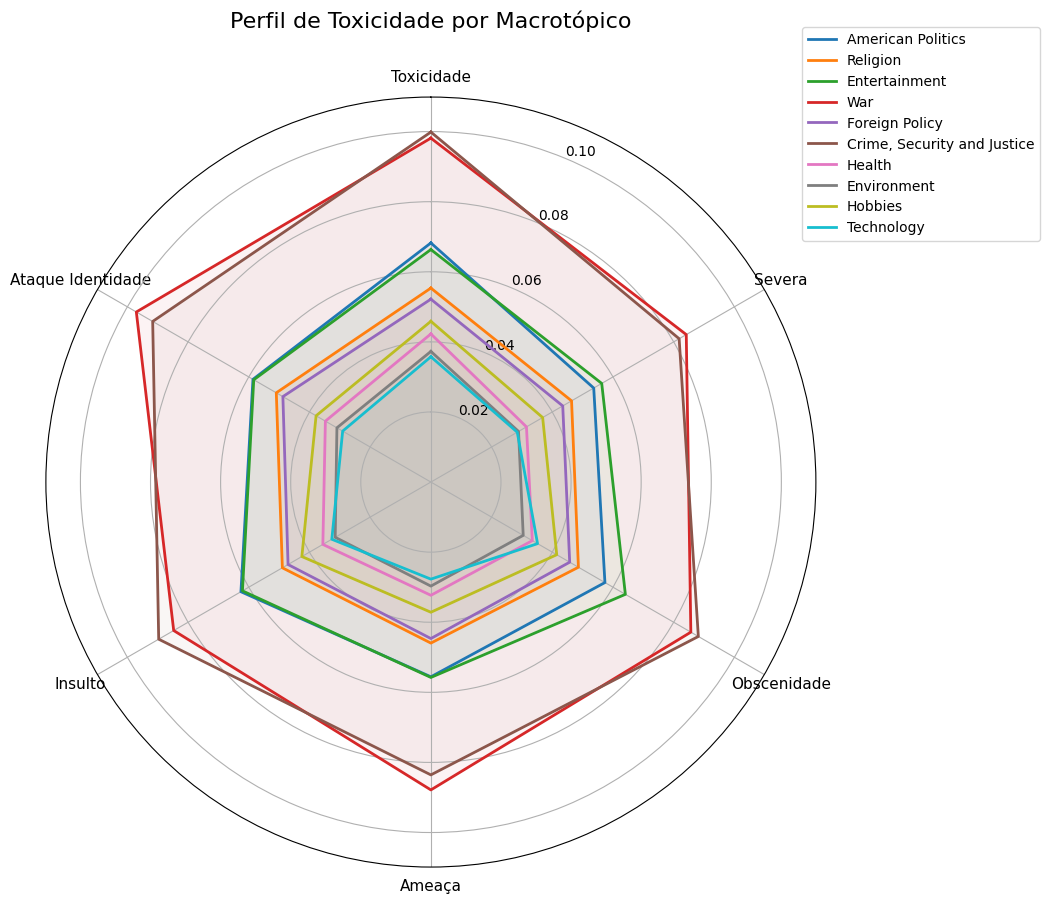

In [2]:
%matplotlib inline
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.cm as cm
from math import pi

# --- Configuração ---
INPUT_FILE = 'data/macrotopics_pred.csv'
# --------------------

try:
    df = pd.read_csv(INPUT_FILE)
except:
    df = pd.read_csv('sample_yt_te_cross_with_topics.csv')

categorias = ['perspective_toxicity', 'perspective_severe_toxicity', 'perspective_obscene',
              'perspective_threat', 'perspective_insult', 'perspective_identity_attack']
labels = ['Toxicidade', 'Severa', 'Obscenidade', 'Ameaça', 'Insulto', 'Ataque Identidade']

topicos_alvo = [
    'American Politics', 'Religion', 'Entertainment', 'War', 'Foreign Policy', 
    'Crime, Security and Justice', 'Health', 'Environment', 'Hobbies', 'Technology'
]

# Filtra apenas tópicos existentes
validos = [t for t in topicos_alvo if t in df['macrotopic_pred'].unique()]
df_radar = df[df['macrotopic_pred'].isin(validos)].groupby('macrotopic_pred')[categorias].mean()

# Função do Radar
def make_radar(df, topicos, labels):
    N = len(labels)
    angles = [n / float(N) * 2 * pi for n in range(N)]
    angles += angles[:1]
    
    plt.figure(figsize=(10, 10))
    ax = plt.subplot(111, polar=True)
    ax.set_theta_offset(pi / 2)
    ax.set_theta_direction(-1)
    
    plt.xticks(angles[:-1], labels, size=11)
    plt.ylim(0, df.values.max() * 1.1)
    
    colors = cm.tab10(np.linspace(0, 1, len(topicos)))
    
    for i, topico in enumerate(topicos):
        values = df.loc[topico].values.flatten().tolist()
        values += values[:1]
        ax.plot(angles, values, linewidth=2, label=topico, color=colors[i])
        ax.fill(angles, values, color=colors[i], alpha=0.05)
        
    plt.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))
    plt.title('Perfil de Toxicidade por Macrotópico', y=1.08, fontsize=16)
    plt.show()

make_radar(df_radar, validos, labels)

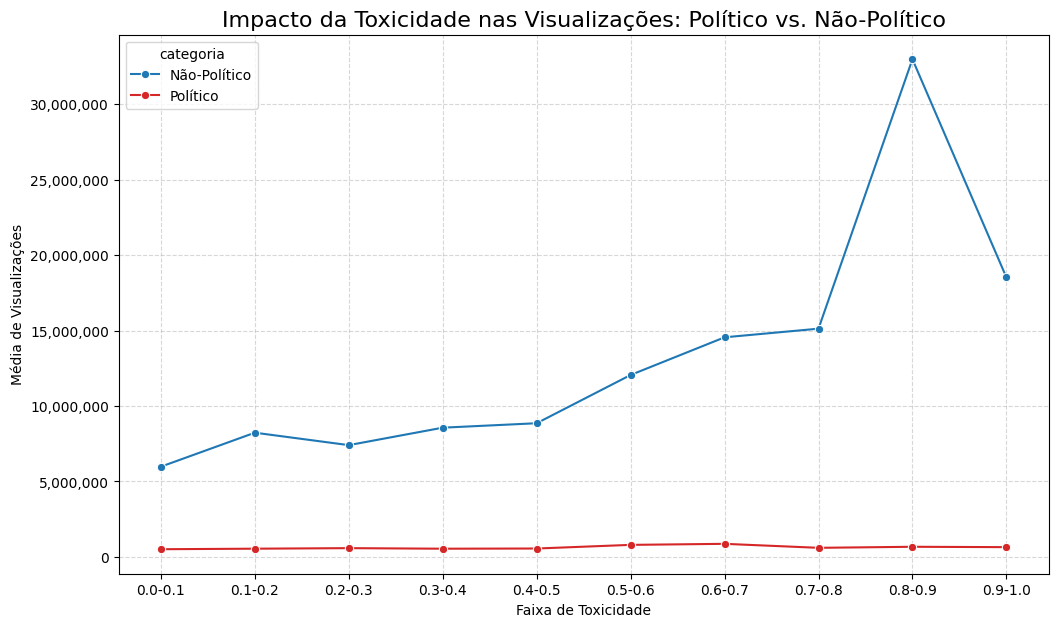

In [4]:
%matplotlib inline
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as ticker
import numpy as np

# --- Configuração ---
INPUT_FILE = 'data/macrotopics_pred.csv'
try: df = pd.read_csv(INPUT_FILE)
except: df = pd.read_csv('sample_yt_te_cross_with_topics.csv')

# Classificação
political = ['American Politics', 'War', 'Foreign Policy', 'Crime, Security and Justice']
non_political = ['Health', 'Environment', 'Religion', 'Entertainment', 'Hobbies', 'Technology']

def classify(t):
    if t in political: return 'Político'
    elif t in non_political: return 'Não-Político'
    else: return 'Outros'

df['categoria'] = df['macrotopic_pred'].apply(classify)
df_comp = df[df['categoria'].isin(['Político', 'Não-Político'])].copy()
df_comp['view_count'] = pd.to_numeric(df_comp['view_count'], errors='coerce').fillna(0)

# Bins
bins = np.arange(0, 1.1, 0.1)
labels_bin = [f'{i:.1f}-{i+0.1:.1f}' for i in np.arange(0, 1.0, 0.1)]
df_comp['toxicity_bin'] = pd.cut(df_comp['perspective_toxicity'], bins=bins, labels=labels_bin)

# Gráfico
plt.figure(figsize=(12, 7))
sns.lineplot(
    x='toxicity_bin', y='view_count', hue='categoria', 
    data=df_comp, marker='o', errorbar=None,
    palette={'Político': '#d62728', 'Não-Político': '#1f77b4'}
)
plt.title('Impacto da Toxicidade nas Visualizações: Político vs. Não-Político', fontsize=16)
plt.ylabel('Média de Visualizações')
plt.xlabel('Faixa de Toxicidade')
plt.gca().yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, p: format(int(x), ',')))
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

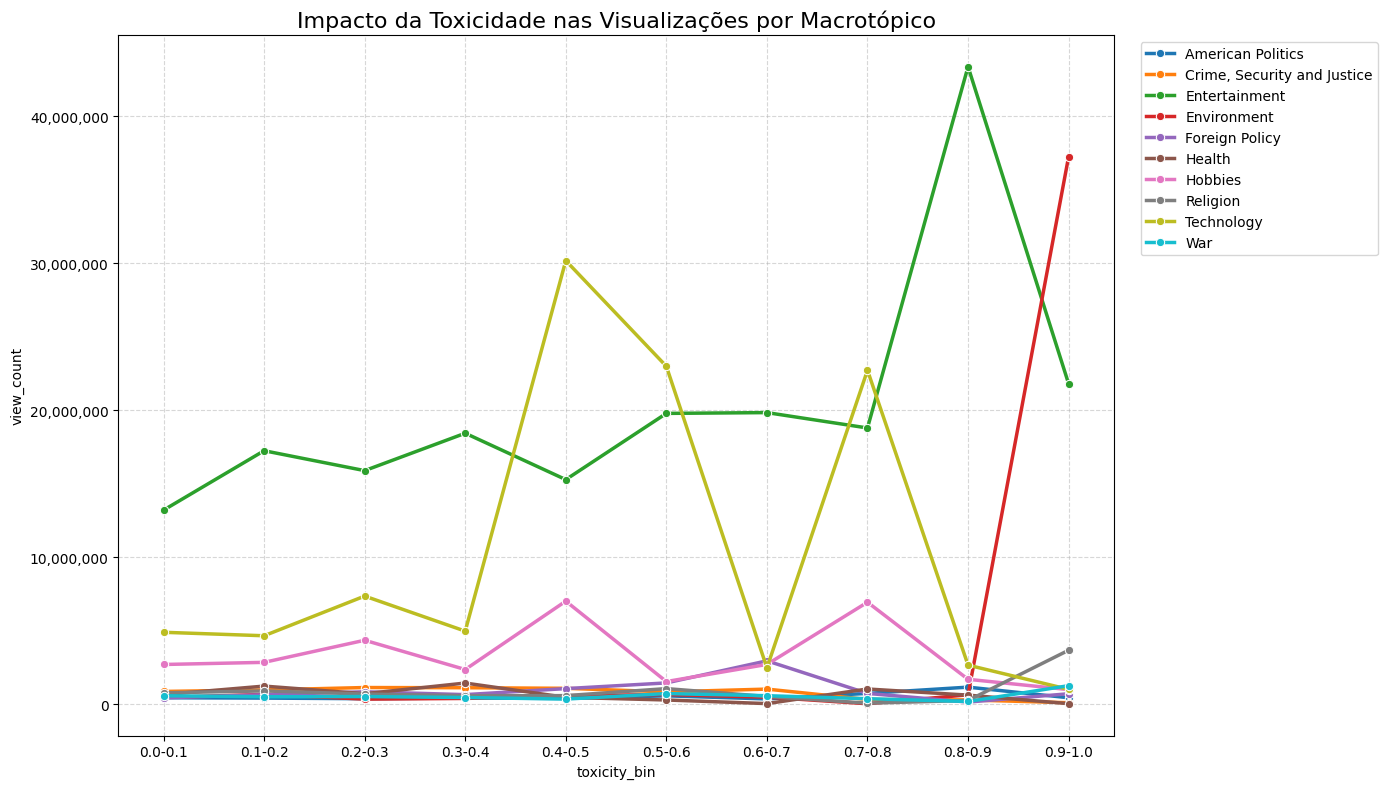

In [5]:
%matplotlib inline
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import matplotlib.ticker as ticker

# --- Configuração ---
INPUT_FILE = 'data/macrotopics_pred.csv'
try: df = pd.read_csv(INPUT_FILE)
except: df = pd.read_csv('sample_yt_te_cross_with_topics.csv')

topicos_alvo = [
    'American Politics', 'War', 'Foreign Policy', 'Crime, Security and Justice',
    'Entertainment', 'Religion', 'Hobbies', 'Technology', 'Health', 'Environment'
]

df_filtered = df[df['macrotopic_pred'].isin(topicos_alvo)].copy()
df_filtered['view_count'] = pd.to_numeric(df_filtered['view_count'], errors='coerce').fillna(0)

# Bins
bins = np.arange(0, 1.1, 0.1)
labels_bin = [f'{i:.1f}-{i+0.1:.1f}' for i in np.arange(0, 1.0, 0.1)]
df_filtered['toxicity_bin'] = pd.cut(df_filtered['perspective_toxicity'], bins=bins, labels=labels_bin)

# Agrega para ficar rápido
df_agg = df_filtered.groupby(['macrotopic_pred', 'toxicity_bin'], observed=False)['view_count'].mean().reset_index()

plt.figure(figsize=(14, 8))
sns.lineplot(
    x='toxicity_bin', y='view_count', hue='macrotopic_pred', 
    data=df_agg, marker='o', palette='tab10', linewidth=2.5
)
plt.title('Impacto da Toxicidade nas Visualizações por Macrotópico', fontsize=16)
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.5)
plt.gca().yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, p: format(int(x), ',')))
plt.tight_layout()
plt.show()

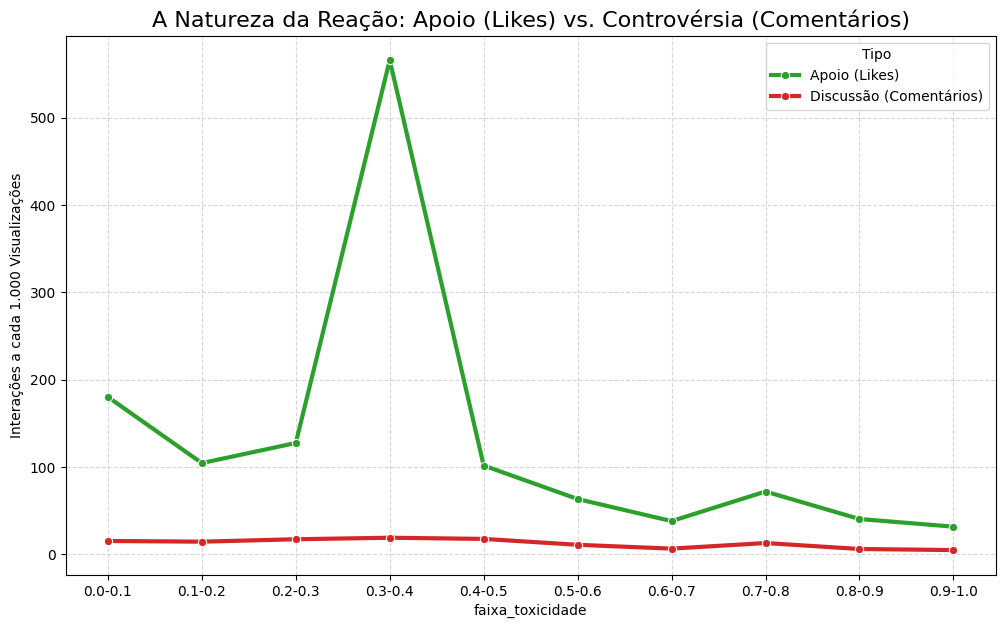

In [6]:
%matplotlib inline
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# --- Configuração ---
INPUT_FILE = 'data/macrotopics_pred.csv'
try: df = pd.read_csv(INPUT_FILE)
except: df = pd.read_csv('sample_yt_te_cross_with_topics.csv')

df['view_count'] = pd.to_numeric(df['view_count'], errors='coerce').fillna(0)
df['like_count'] = pd.to_numeric(df['like_count'], errors='coerce').fillna(0)
df['comment_count'] = pd.to_numeric(df['comment_count'], errors='coerce').fillna(0)

# Métricas Relativas
df['likes_por_1k'] = (df['like_count'] / (df['view_count'] + 100)) * 1000
df['comments_por_1k'] = (df['comment_count'] / (df['view_count'] + 100)) * 1000

# Bins
bins = np.arange(0, 1.1, 0.1)
labels_bin = [f'{i:.1f}-{i+0.1:.1f}' for i in np.arange(0, 1.0, 0.1)]
df['faixa_toxicidade'] = pd.cut(df['perspective_toxicity'], bins=bins, labels=labels_bin)

# Agrupa e derrete (melt) para o seaborn
df_grouped = df.groupby('faixa_toxicidade', observed=False)[['likes_por_1k', 'comments_por_1k']].mean().reset_index()
df_melted = df_grouped.melt('faixa_toxicidade', var_name='Tipo', value_name='Taxa')
df_melted['Tipo'] = df_melted['Tipo'].replace({'likes_por_1k': 'Apoio (Likes)', 'comments_por_1k': 'Discussão (Comentários)'})

plt.figure(figsize=(12, 7))
sns.lineplot(
    x='faixa_toxicidade', y='Taxa', hue='Tipo', 
    data=df_melted, marker='o', linewidth=3,
    palette={'Apoio (Likes)': '#2ca02c', 'Discussão (Comentários)': '#d62728'}
)
plt.title('A Natureza da Reação: Apoio (Likes) vs. Controvérsia (Comentários)', fontsize=16)
plt.ylabel('Interações a cada 1.000 Visualizações')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()